In [1]:
import pandas as pd
import matplotlib.pyplot as plt
ImportWarning 

df=pd.read_csv('C:/Users/chauh/OneDrive/Desktop/Smart-sale/data/cleared/clean_sales.csv')
df.columns

Index(['Unnamed: 0', 'order_id', 'order_date', 'ship_date', 'Ship_mode',
       'Customer_id', 'Customer_Name', 'Segment', 'City', 'State', 'Country',
       'Region', 'Market', 'Product_id', 'Category', 'sub_category',
       'product_name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'shipping_cost', 'order_priority', 'Delivery_days', 'order_year',
       'order_month'],
      dtype='str')

In [2]:
df_eda=df.copy()
df_eda= df_eda.rename(columns={'Sales': 'sales', 'Quantity': 'quantity', 'Discount': 'discount', 'Profit': 'profit','Category': 'category', 'Sub_Category': 'sub_category','Delivery_days': 'delivery_days','Market': 'market','Region': 'region', 'Segment': 'segment','Ship_mode': 'ship_mode'}) 

EDA

In [3]:

df_eda= df_eda.drop(columns=['Unnamed: 0', 'order_id','Customer_id', 'Customer_Name','product_name', 'Product_id',
                        'City', 'State', 'Country' ,'ship_date', 'order_priority' ])
df_eda.head()

,order_date,ship_mode,segment,region,market,category,sub_category,sales,quantity,discount,profit,shipping_cost,delivery_days,order_year,order_month
0,11-11-2014,First Class,Consumer,Central US,USCA,Technology,Phones,221,2,0.0,62,40,2,2014,11
1,05-02-2014,Second Class,Corporate,Oceania,Asia Pacific,Furniture,Chairs,3709,9,0.1,-288,923,2,2014,2
2,17-10-2014,First Class,Consumer,Oceania,Asia Pacific,Technology,Phones,5175,9,0.1,919,915,1,2014,10
3,28-01-2014,First Class,Home Office,Western Europe,Europe,Technology,Phones,2892,5,0.1,-96,910,2,2014,1
4,05-11-2014,Same Day,Consumer,Western Africa,Africa,Technology,Copiers,2832,8,0.0,311,903,1,2014,11


In [4]:
print(df_eda.shape)
print(df_eda.info())
print(df_eda.isnull().sum())
print(df_eda["sales"].describe())

(51290, 15)
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_date     51290 non-null  str    
 1   ship_mode      51290 non-null  str    
 2   segment        51290 non-null  str    
 3   region         51290 non-null  str    
 4   market         51290 non-null  str    
 5   category       51290 non-null  str    
 6   sub_category   51290 non-null  str    
 7   sales          51290 non-null  int64  
 8   quantity       51290 non-null  int64  
 9   discount       51290 non-null  float64
 10  profit         51290 non-null  int64  
 11  shipping_cost  51290 non-null  int64  
 12  delivery_days  51290 non-null  int64  
 13  order_year     51290 non-null  int64  
 14  order_month    51290 non-null  int64  
dtypes: float64(1), int64(7), str(7)
memory usage: 5.9 MB
None
order_date       0
ship_mode        0
segment          0
region           0
mar

In [5]:
df_eda["order_date"] = pd.to_datetime(df_eda["order_date"], format="%d-%m-%Y")

In [6]:
df_eda.duplicated().sum()

np.int64(6)

In [7]:
df_eda.drop_duplicates(inplace=True)

In [8]:
import numpy as np
y = np.log1p(df_eda["sales"])
X = df_eda.drop("sales", axis=1)

In [9]:
print(X.shape)
print(y.shape)

(51284, 14)
(51284,)


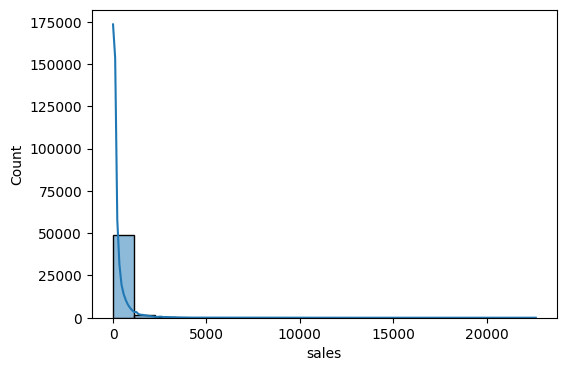

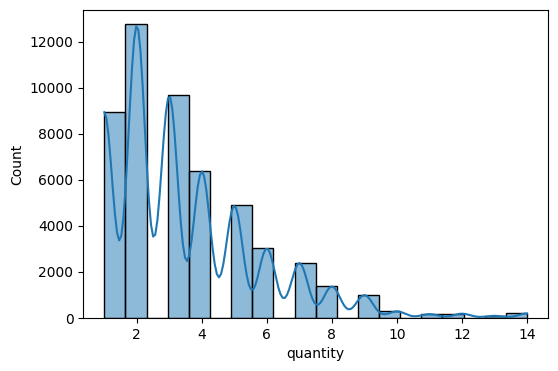

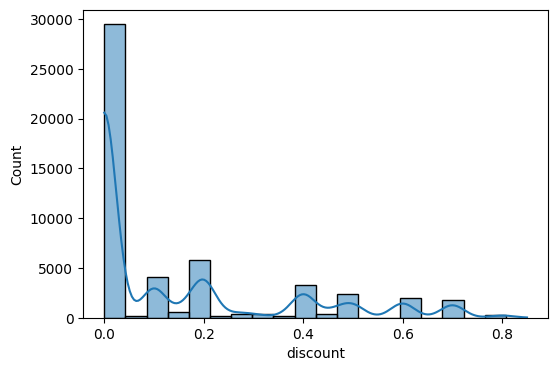

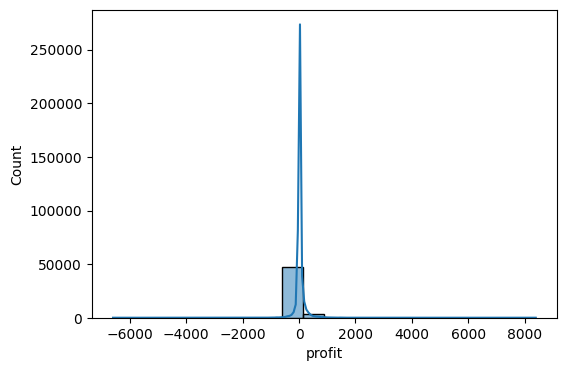

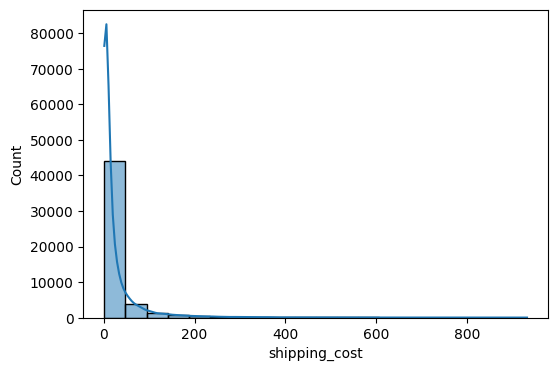

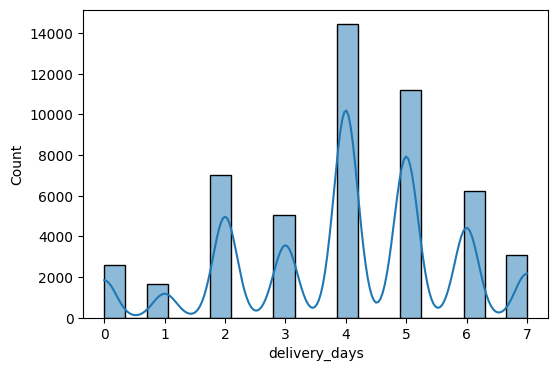

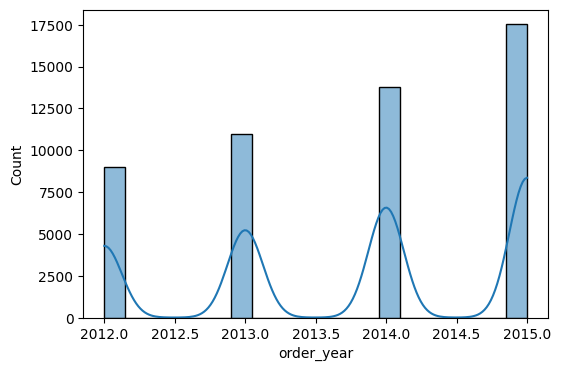

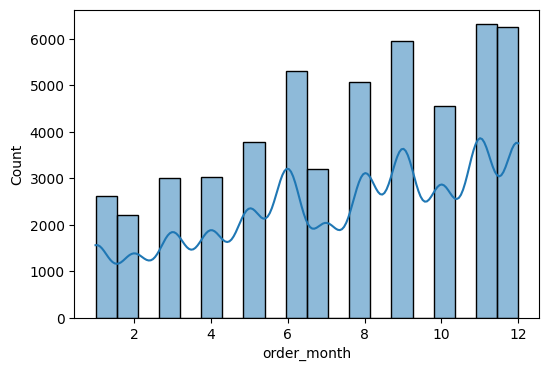

In [10]:
import seaborn as sns
numeric_columns = ['sales', 'quantity', 'discount',	'profit','shipping_cost','delivery_days','order_year','order_month']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_eda[col],kde = True,bins = 20)

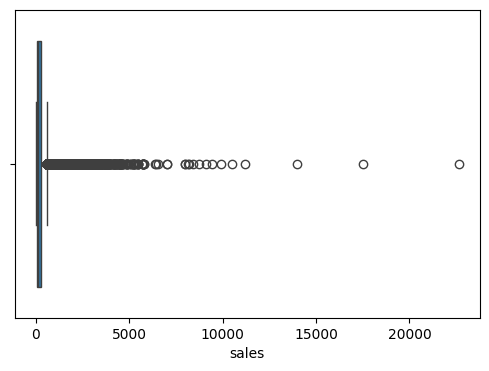

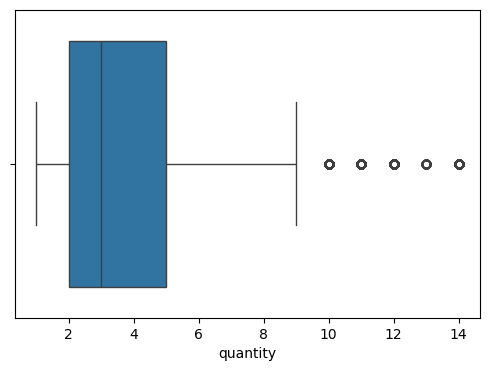

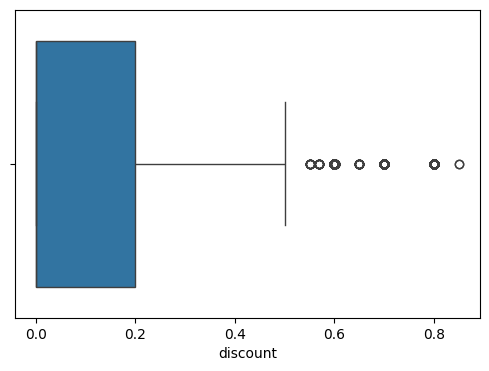

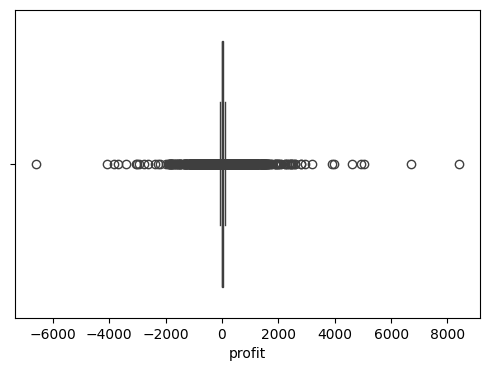

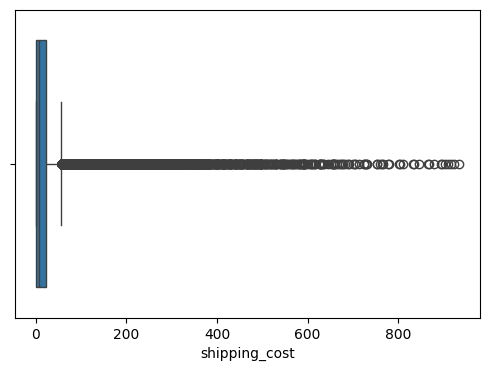

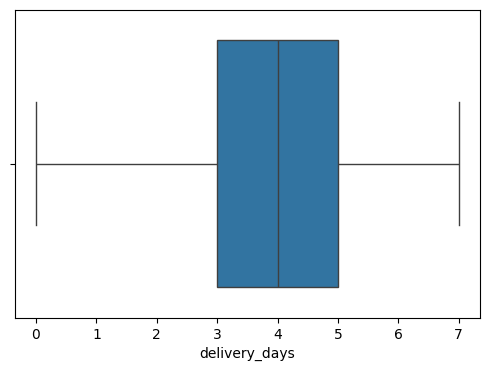

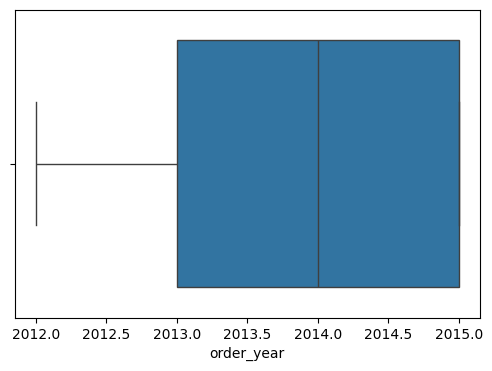

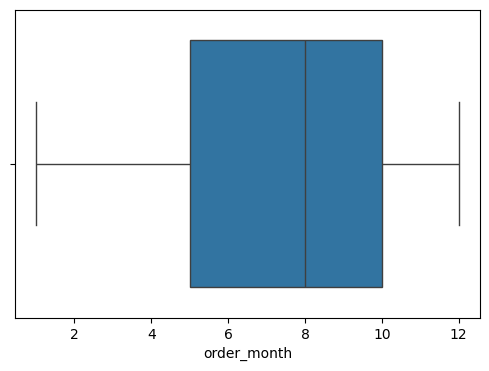

In [11]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df_eda[col],)

In [12]:
df_eda.columns

Index(['order_date', 'ship_mode', 'segment', 'region', 'market', 'category',
       'sub_category', 'sales', 'quantity', 'discount', 'profit',
       'shipping_cost', 'delivery_days', 'order_year', 'order_month'],
      dtype='str')

In [13]:
df_eda = pd.get_dummies(df_eda,'ship_mode',drop_first=True)

In [14]:
df_eda = pd.get_dummies(df_eda,'segment',drop_first=True)

In [15]:
df_eda = pd.get_dummies(df_eda,'region',drop_first=True)

In [16]:
df_eda = pd.get_dummies(df_eda,'market',drop_first=True)

In [17]:
df_eda = pd.get_dummies(df_eda,'category',drop_first=True)

In [18]:
df_eda = pd.get_dummies(df_eda,'sub_category',drop_first=True)

In [19]:
df_eda.columns

Index(['order_date', 'sales', 'quantity', 'discount', 'profit',
       'shipping_cost', 'delivery_days', 'order_year', 'order_month',
       'ship_mode_Same Day', 'ship_mode_Second Class',
       'ship_mode_Standard Class', 'ship_mode_Corporate',
       'ship_mode_Home Office', 'ship_mode_Caribbean',
       'ship_mode_Central Africa', 'ship_mode_Central America',
       'ship_mode_Central Asia', 'ship_mode_Central US',
       'ship_mode_Eastern Africa', 'ship_mode_Eastern Asia',
       'ship_mode_Eastern Europe', 'ship_mode_Eastern US',
       'ship_mode_North Africa', 'ship_mode_Northern Europe',
       'ship_mode_Oceania', 'ship_mode_South America',
       'ship_mode_Southeastern Asia', 'ship_mode_Southern Africa',
       'ship_mode_Southern Asia', 'ship_mode_Southern Europe',
       'ship_mode_Southern US', 'ship_mode_Western Africa',
       'ship_mode_Western Asia', 'ship_mode_Western Europe',
       'ship_mode_Western US', 'ship_mode_Asia Pacific', 'ship_mode_Europe',
       'ship

In [20]:
df_eda.head()

,order_date,sales,quantity,discount,profit,shipping_cost,delivery_days,order_year,order_month,ship_mode_Same Day,...,ship_mode_Envelopes,ship_mode_Fasteners,ship_mode_Furnishings,ship_mode_Labels,ship_mode_Machines,ship_mode_Paper,ship_mode_Phones,ship_mode_Storage,ship_mode_Supplies,ship_mode_Tables
0,2014-11-11,221,2,0.0,62,40,2,2014,11,False,...,False,False,False,False,False,False,True,False,False,False
1,2014-02-05,3709,9,0.1,-288,923,2,2014,2,False,...,False,False,False,False,False,False,False,False,False,False
2,2014-10-17,5175,9,0.1,919,915,1,2014,10,False,...,False,False,False,False,False,False,True,False,False,False
3,2014-01-28,2892,5,0.1,-96,910,2,2014,1,False,...,False,False,False,False,False,False,True,False,False,False
4,2014-11-05,2832,8,0.0,311,903,1,2014,11,True,...,False,False,False,False,False,False,False,False,False,False


In [21]:
df_eda.dtypes

order_date                     datetime64[us]
sales                                   int64
quantity                                int64
discount                              float64
profit                                  int64
shipping_cost                           int64
delivery_days                           int64
order_year                              int64
order_month                             int64
ship_mode_Same Day                       bool
ship_mode_Second Class                   bool
ship_mode_Standard Class                 bool
ship_mode_Corporate                      bool
ship_mode_Home Office                    bool
ship_mode_Caribbean                      bool
ship_mode_Central Africa                 bool
ship_mode_Central America                bool
ship_mode_Central Asia                   bool
ship_mode_Central US                     bool
ship_mode_Eastern Africa                 bool
ship_mode_Eastern Asia                   bool
ship_mode_Eastern Europe          

In [22]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = [ 'profit','quantity', 'discount', 'shipping_cost',
       'delivery_days']
scaler = StandardScaler()
df_eda[cols_to_scale] = scaler.fit_transform(df_eda[cols_to_scale])
df_eda



,order_date,sales,quantity,discount,profit,shipping_cost,delivery_days,order_year,order_month,ship_mode_Same Day,...,ship_mode_Envelopes,ship_mode_Fasteners,ship_mode_Furnishings,ship_mode_Labels,ship_mode_Machines,ship_mode_Paper,ship_mode_Phones,ship_mode_Storage,ship_mode_Supplies,ship_mode_Tables
0,2014-11-11,221,-0.647977,-0.673214,0.193087,0.244722,-1.138686,2014,11,False,...,False,False,False,False,False,False,True,False,False,False
1,2014-02-05,3709,2.423753,-0.202089,-1.816084,15.667177,-1.138686,2014,2,False,...,False,False,False,False,False,False,False,False,False,False
2,2014-10-17,5175,2.423753,-0.202089,5.112686,15.527449,-1.716925,2014,10,False,...,False,False,False,False,False,False,True,False,False,False
3,2014-01-28,2892,0.668479,-0.202089,-0.713910,15.440119,-1.138686,2014,1,False,...,False,False,False,False,False,False,True,False,False,False
4,2014-11-05,2832,1.984934,-0.673214,1.622469,15.317857,-1.716925,2014,11,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2015-06-19,65,0.668479,-0.673214,-0.139861,-0.436451,-2.295164,2015,6,True,...,False,True,False,False,False,False,False,False,False,False
51286,2014-05-06,16,0.668479,0.269036,-0.145601,-0.436451,0.017792,2014,5,False,...,False,False,True,False,False,False,False,False,False,False
51287,2012-08-26,8,-0.647977,-0.673214,-0.151342,-0.436451,0.596031,2012,8,False,...,False,False,False,False,False,False,False,False,False,False
51288,2013-02-17,13,-0.647977,-0.673214,-0.151342,-0.436451,0.017792,2013,2,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
df_eda=df_eda.astype(int)
df_eda.to_pickle('C:/Users/chauh/OneDrive/Desktop/Smart-sale/data/cleared/clean_sales_eda.pkl')

In [24]:

df_final=pd.read_pickle('C:/Users/chauh/OneDrive/Desktop/Smart-sale/data/cleared/clean_sales_eda.pkl')

In [25]:
df_final.head()

,order_date,sales,quantity,discount,profit,shipping_cost,delivery_days,order_year,order_month,ship_mode_Same Day,...,ship_mode_Envelopes,ship_mode_Fasteners,ship_mode_Furnishings,ship_mode_Labels,ship_mode_Machines,ship_mode_Paper,ship_mode_Phones,ship_mode_Storage,ship_mode_Supplies,ship_mode_Tables
0,1415664000000000,221,0,0,0,0,-1,2014,11,0,...,0,0,0,0,0,0,1,0,0,0
1,1391558400000000,3709,2,0,-1,15,-1,2014,2,0,...,0,0,0,0,0,0,0,0,0,0
2,1413504000000000,5175,2,0,5,15,-1,2014,10,0,...,0,0,0,0,0,0,1,0,0,0
3,1390867200000000,2892,0,0,0,15,-1,2014,1,0,...,0,0,0,0,0,0,1,0,0,0
4,1415145600000000,2832,1,0,1,15,-1,2014,11,1,...,0,0,0,0,0,0,0,0,0,0


In [26]:
df_final.columns

Index(['order_date', 'sales', 'quantity', 'discount', 'profit',
       'shipping_cost', 'delivery_days', 'order_year', 'order_month',
       'ship_mode_Same Day', 'ship_mode_Second Class',
       'ship_mode_Standard Class', 'ship_mode_Corporate',
       'ship_mode_Home Office', 'ship_mode_Caribbean',
       'ship_mode_Central Africa', 'ship_mode_Central America',
       'ship_mode_Central Asia', 'ship_mode_Central US',
       'ship_mode_Eastern Africa', 'ship_mode_Eastern Asia',
       'ship_mode_Eastern Europe', 'ship_mode_Eastern US',
       'ship_mode_North Africa', 'ship_mode_Northern Europe',
       'ship_mode_Oceania', 'ship_mode_South America',
       'ship_mode_Southeastern Asia', 'ship_mode_Southern Africa',
       'ship_mode_Southern Asia', 'ship_mode_Southern Europe',
       'ship_mode_Southern US', 'ship_mode_Western Africa',
       'ship_mode_Western Asia', 'ship_mode_Western Europe',
       'ship_mode_Western US', 'ship_mode_Asia Pacific', 'ship_mode_Europe',
       'ship

In [27]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'order_date', 'sales', 'quantity', 'discount', 'profit',
       'shipping_cost', 'delivery_days', 'order_year', 'order_month',
       'ship_mode_Same Day', 'ship_mode_Second Class',
       'ship_mode_Standard Class', 'ship_mode_Corporate',
       'ship_mode_Home Office', 'ship_mode_Caribbean',
       'ship_mode_Central Africa', 'ship_mode_Central America',
       'ship_mode_Central Asia', 'ship_mode_Central US',
       'ship_mode_Eastern Africa', 'ship_mode_Eastern Asia',
       'ship_mode_Eastern Europe', 'ship_mode_Eastern US',
       'ship_mode_North Africa', 'ship_mode_Northern Europe',
       'ship_mode_Oceania', 'ship_mode_South America',
       'ship_mode_Southeastern Asia', 'ship_mode_Southern Africa',
       'ship_mode_Southern Asia', 'ship_mode_Southern Europe',
       'ship_mode_Southern US', 'ship_mode_Western Africa',
       'ship_mode_Western Asia', 'ship_mode_Western Europe',
       'ship_mode_Western US', 'ship_mode_Asia Pacific', 'ship_mode_Europe',
       'ship_mode_LATAM', 'ship_mode_USCA', 'ship_mode_Office Supplies',
       'ship_mode_Technology', 'ship_mode_Appliances', 'ship_mode_Art',
       'ship_mode_Binders', 'ship_mode_Bookcases', 'ship_mode_Chairs',
       'ship_mode_Copiers', 'ship_mode_Envelopes', 'ship_mode_Fasteners',
       'ship_mode_Furnishings', 'ship_mode_Labels', 'ship_mode_Machines',
       'ship_mode_Paper', 'ship_mode_Phones', 'ship_mode_Storage',
       'ship_mode_Supplies', 'ship_mode_Tables']

correlations = {
    feature: pearsonr(df_final[feature], df_final['sales'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
1,sales,1.000000
5,shipping_cost,0.677389
4,profit,0.432644
2,quantity,0.278004
41,ship_mode_Technology,0.225355
47,ship_mode_Copiers,0.188813
57,ship_mode_Tables,0.169585
45,ship_mode_Bookcases,0.164804
54,ship_mode_Phones,0.142146
42,ship_mode_Appliances,0.128293


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X = df_final.drop('sales', axis=1)
y = df_final['sales']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
# Predictions
y_pred = model.predict(X_test)

# R2 score
r2 = r2_score(y_test, y_pred)

# n = number of samples
n = X_test.shape[0]

# p = number of features
p = X_test.shape[1]

# Adjusted R2
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

R2: 0.8012234782990795
Adjusted R2: 0.8001125594112519


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Extra metrics
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))